In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_squared_error, r2_score

In [2]:
url = "https://docs.google.com/spreadsheets/d/1olnPzdWRsj3ahZMC4RAnI7gFasnIVTX2apxDtNDeKg8/export?format=csv&gid=2081577189"
df = pd.read_csv(url)

In [3]:
df.head()

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   job_title         250000 non-null  object
 1   experience_years  250000 non-null  int64 
 2   education_level   250000 non-null  object
 3   skills_count      250000 non-null  int64 
 4   industry          250000 non-null  object
 5   company_size      250000 non-null  object
 6   location          250000 non-null  object
 7   remote_work       250000 non-null  object
 8   certifications    250000 non-null  int64 
 9   salary            250000 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 19.1+ MB


In [5]:
df.describe()

,experience_years,skills_count,certifications,salary
count,250000.000000,250000.000000,250000.000000,250000.000000
mean,10.005408,9.997812,2.491928,145718.080524
std,6.060602,5.479288,1.706475,37407.952729
min,0.000000,1.000000,0.000000,31867.000000
25%,5.000000,5.000000,1.000000,119358.000000
50%,10.000000,10.000000,2.000000,143453.000000
75%,15.000000,15.000000,4.000000,169492.000000
max,20.000000,19.000000,5.000000,333046.000000


In [6]:
df.drop("remote_work",axis=1,inplace=True)

In [7]:
df.isnull().sum()

job_title           0
experience_years    0
education_level     0
skills_count        0
industry            0
company_size        0
location            0
certifications      0
salary              0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df.dtypes

job_title           object
experience_years     int64
education_level     object
skills_count         int64
industry            object
company_size        object
location            object
certifications       int64
salary               int64
dtype: object

In [10]:
df["salary"].describe()

count    250000.000000
mean     145718.080524
std       37407.952729
min       31867.000000
25%      119358.000000
50%      143453.000000
75%      169492.000000
max      333046.000000
Name: salary, dtype: float64

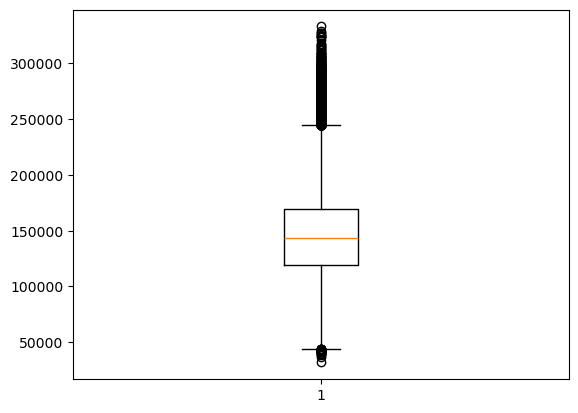

In [11]:
plt.boxplot(df['salary'])
plt.show()

In [12]:
df.columns

Index(['job_title', 'experience_years', 'education_level', 'skills_count',
       'industry', 'company_size', 'location', 'certifications', 'salary'],
      dtype='object')

In [13]:
df[['salary','experience_years']].corr()

,salary,experience_years
salary,1.000000,0.437627
experience_years,0.437627,1.000000


In [14]:
df = pd.get_dummies(df, columns=['job_title', 'industry', 'location'], drop_first=True)

In [15]:
df['education_level'].unique()

array(['Bachelor', 'PhD', 'High School', 'Diploma', 'Master'],
      dtype=object)

In [16]:
df['company_size'].unique()

array(['Medium', 'Small', 'Large', 'Enterprise', 'Startup'], dtype=object)

In [17]:
df['education_level'] = df['education_level'].map({'High School':1,'Diploma':2,'Bachelor':3,'Master':4,'PhD':5})
df['company_size'] = df['company_size'].map({'Startup':1,'Small':2,'Medium':3,'Large':4,'Enterprise':5})

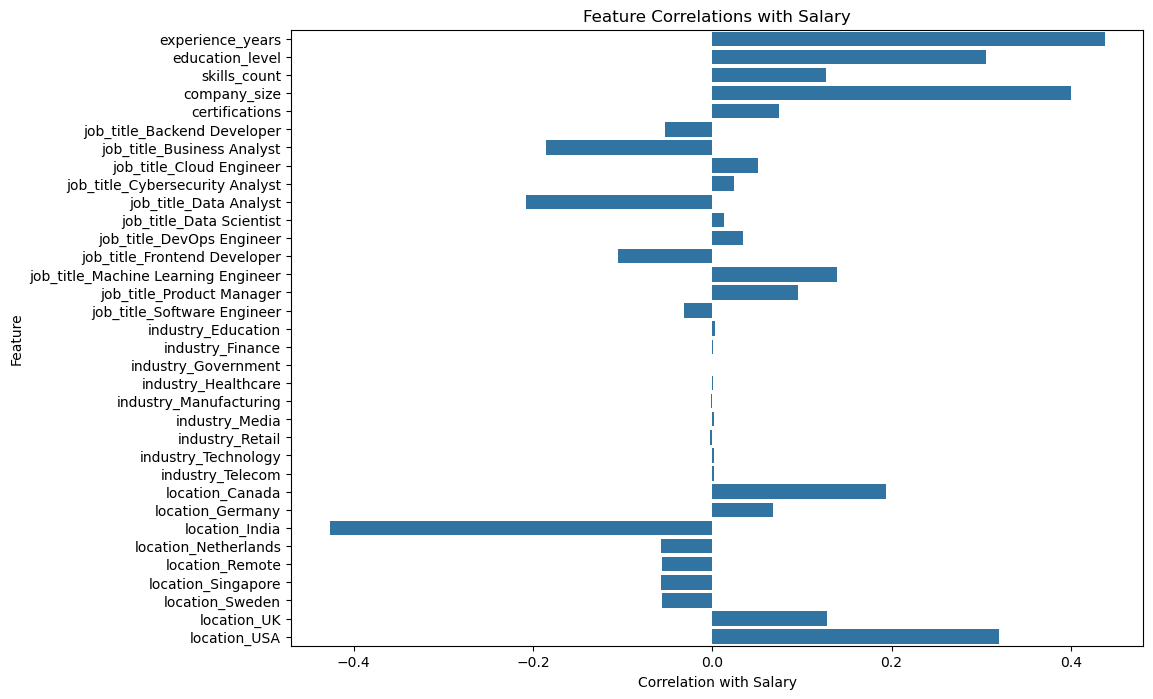

In [18]:
salary_corr = df.corr()['salary']
salary_corr = salary_corr.drop('salary')
plt.figure(figsize=(11,8))
sns.barplot(x=salary_corr.values,y=salary_corr.index)
plt.xlabel("Correlation with Salary")
plt.ylabel("Feature")
plt.title("Feature Correlations with Salary")
plt.show()

In [19]:
X = df.drop('salary',axis=1)
y = df['salary']
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [20]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [21]:
lr = LinearRegression()
lr.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [22]:
predictions = lr.predict(X_test)
print(r2_score(y_test,predictions))
print(mean_squared_error(y_test,predictions))

0.9507338480269403
68473233.00714572


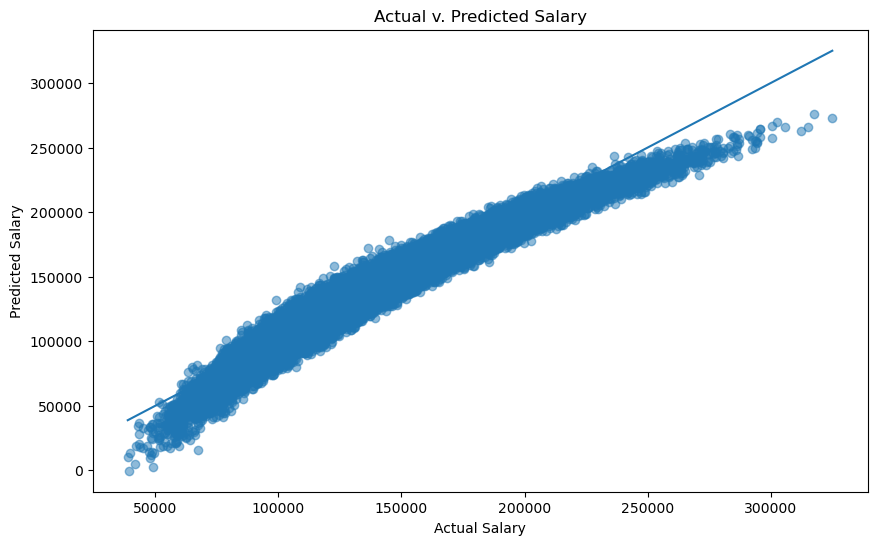

In [24]:
plt.figure(figsize=(10,6))
plt.scatter(y_test,predictions,alpha=0.5)
plt.plot([y_test.min(),y_test.max()],[y_test.min(),y_test.max()])
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual v. Predicted Salary")
plt.show()

In [27]:
rmse = np.sqrt(mean_squared_error(y_test,predictions))
print(rmse)

8274.855467447496


In [29]:
RidgeModel = Ridge(alpha=0.3)
RidgeModel.fit(X_train,y_train)
Yhat = RidgeModel.predict(X_test)
print(r2_score(y_test,Yhat))
print(mean_squared_error(y_test,Yhat))

0.9507338463523337
68473235.33462055


In [32]:
for alpha in [0.1,1,10,100]:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train,y_train)
    Yhat2 = ridge.predict(X_test)
    print(alpha,r2_score(y_test,Yhat2))

0.1 0.950733847472347
1 0.9507338423186193
10 0.9507337747207143
100 0.9507315082817981
